# Probability of Nth recall

Probability of recalling each clip position at each output position. The key question is whether voluntary recall shows a primacy bias at early output positions (consistent with starting-context reinstatement) that involuntary recall lacks.

In [1]:
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.pnr import plot_pnr
from jaxcmr.helpers import find_project_root, load_data

warnings.filterwarnings("ignore")

In [2]:
run_tag = "VRT_PNR"
data_path = "data/VRT_clips.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
size = 3
query_recall_position = 0

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)

task = data["task"]
condition = data["condition"]
intervention = data["intervention"]


def trial_mask(mask):
    return jnp.asarray(mask).reshape(-1)


def summarize_masks(labels, masks):
    for label, mask in zip(labels, masks):
        n_trials = int(jnp.sum(mask))
        n_subjects = int(jnp.unique(data["subject"][mask]).size)
        print(f"{label}: trials={n_trials}, subjects={n_subjects}")


def plot_contrast(masks, labels, contrast_name, axis=None, suffix=None):
    plot_pnr(
        datasets=[data] * len(masks),
        trial_masks=masks,
        labels=labels,
        contrast_name=contrast_name,
        axis=axis,
        size=size,
        query_recall_position=query_recall_position,
    )
    if ylim is not None:
        for ax in plt.gcf().axes:
            ax.set_ylim(ylim)
    if axis is None:
        save_figure(figure_dir, figure_str, suffix=suffix or contrast_name)


def save_figure(fig_dir, fig_str, suffix=None):
    if not fig_str:
        plt.show()
        return
    os.makedirs(fig_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    path = os.path.join(fig_dir, f"{fig_str}{suffix_str}.png")
    plt.savefig(path, bbox_inches="tight", dpi=600)
    plt.show()


print(f"Loaded {data['recalls'].shape[0]} trials")

Loaded 240 trials


## Task (involuntary vs voluntary)

Involuntary: trials=120, subjects=120
Voluntary: trials=120, subjects=120


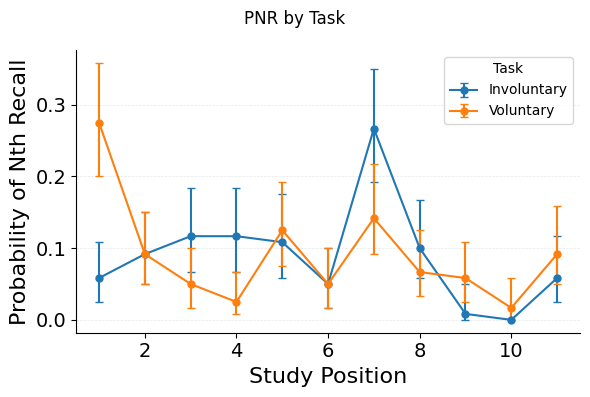

In [4]:
labels = ["Involuntary", "Voluntary"]
masks = [trial_mask(task == 1), trial_mask(task == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, contrast_name="Task", axis=ax)
fig.suptitle("PNR by Task")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task")

## Condition (emotional vs neutral)

Emotional: trials=120, subjects=120
Neutral: trials=120, subjects=120


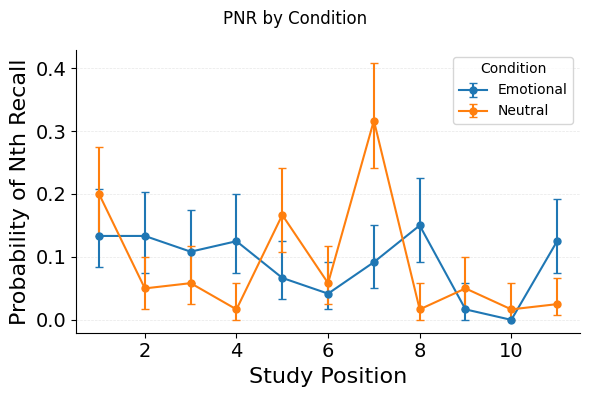

In [5]:
labels = ["Emotional", "Neutral"]
masks = [trial_mask(condition == 1), trial_mask(condition == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, contrast_name="Condition", axis=ax)
fig.suptitle("PNR by Condition")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="condition")

## Intervention (podcast vs Tetris)

Podcast: trials=120, subjects=120
Tetris: trials=120, subjects=120


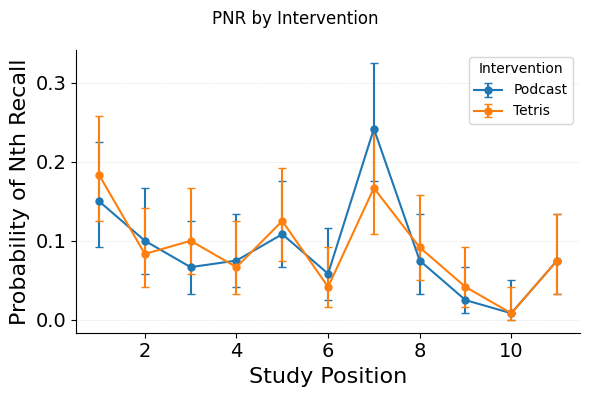

In [6]:
labels = ["Podcast", "Tetris"]
masks = [trial_mask(intervention == 0), trial_mask(intervention == 1)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, contrast_name="Intervention", axis=ax)
fig.suptitle("PNR by Intervention")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention")

## Task x Condition

Invol+Emotional: trials=60, subjects=60
Invol+Neutral: trials=60, subjects=60


Vol+Emotional: trials=60, subjects=60
Vol+Neutral: trials=60, subjects=60


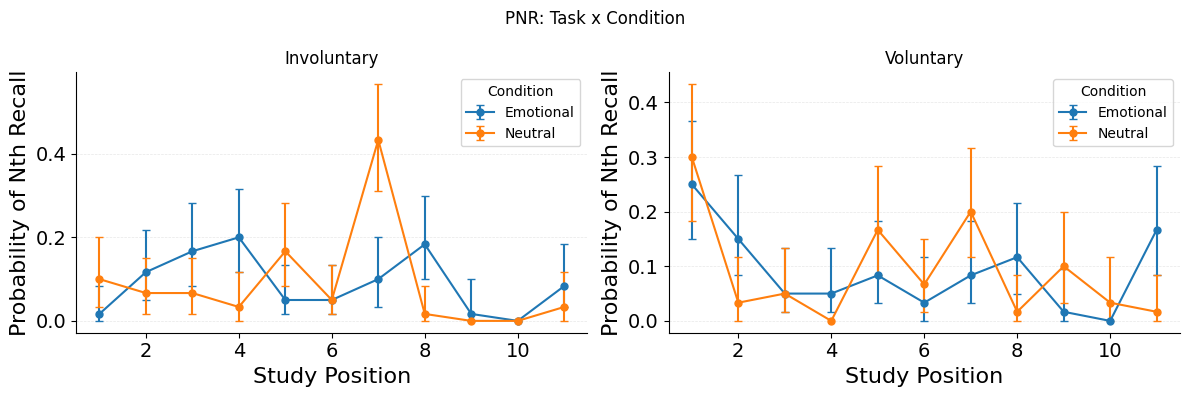

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Involuntary by condition
labels = ["Emotional", "Neutral"]
masks = [
    trial_mask((task == 1) & (condition == 1)),
    trial_mask((task == 1) & (condition == 2)),
]
summarize_masks([f"Invol+{l}" for l in labels], masks)
plot_contrast(masks, labels, contrast_name="Condition", axis=axes[0])
axes[0].set_title("Involuntary")

# Voluntary by condition
masks = [
    trial_mask((task == 2) & (condition == 1)),
    trial_mask((task == 2) & (condition == 2)),
]
summarize_masks([f"Vol+{l}" for l in labels], masks)
plot_contrast(masks, labels, contrast_name="Condition", axis=axes[1])
axes[1].set_title("Voluntary")

fig.suptitle("PNR: Task x Condition")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_condition")

## Task x Intervention

Invol+Podcast: trials=60, subjects=60
Invol+Tetris: trials=60, subjects=60


Vol+Podcast: trials=60, subjects=60
Vol+Tetris: trials=60, subjects=60


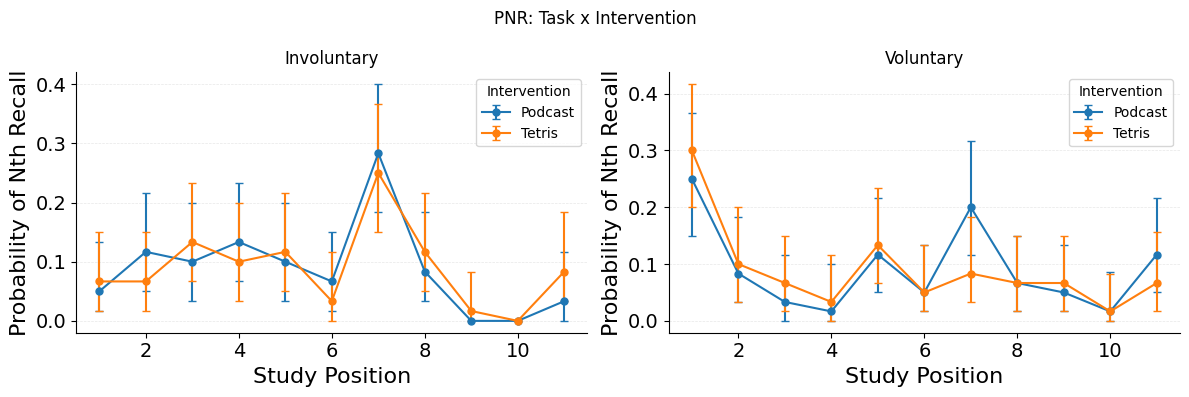

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Involuntary by intervention
labels = ["Podcast", "Tetris"]
masks = [
    trial_mask((task == 1) & (intervention == 0)),
    trial_mask((task == 1) & (intervention == 1)),
]
summarize_masks([f"Invol+{l}" for l in labels], masks)
plot_contrast(masks, labels, contrast_name="Intervention", axis=axes[0])
axes[0].set_title("Involuntary")

# Voluntary by intervention
masks = [
    trial_mask((task == 2) & (intervention == 0)),
    trial_mask((task == 2) & (intervention == 1)),
]
summarize_masks([f"Vol+{l}" for l in labels], masks)
plot_contrast(masks, labels, contrast_name="Intervention", axis=axes[1])
axes[1].set_title("Voluntary")

fig.suptitle("PNR: Task x Intervention")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_intervention")

## Condition x Intervention

Emot+Podcast: trials=60, subjects=60
Emot+Tetris: trials=60, subjects=60


Neut+Podcast: trials=60, subjects=60
Neut+Tetris: trials=60, subjects=60


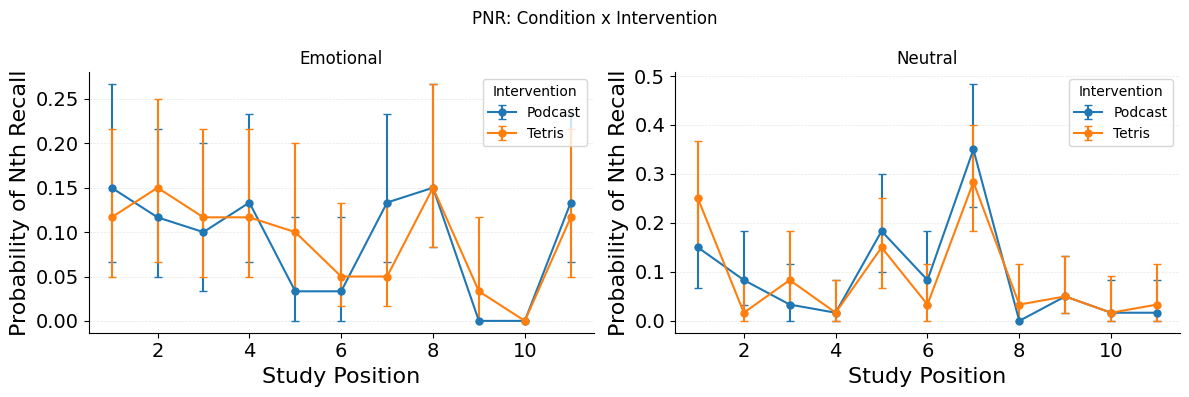

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Emotional by intervention
labels = ["Podcast", "Tetris"]
masks = [
    trial_mask((condition == 1) & (intervention == 0)),
    trial_mask((condition == 1) & (intervention == 1)),
]
summarize_masks([f"Emot+{l}" for l in labels], masks)
plot_contrast(masks, labels, contrast_name="Intervention", axis=axes[0])
axes[0].set_title("Emotional")

# Neutral by intervention
masks = [
    trial_mask((condition == 2) & (intervention == 0)),
    trial_mask((condition == 2) & (intervention == 1)),
]
summarize_masks([f"Neut+{l}" for l in labels], masks)
plot_contrast(masks, labels, contrast_name="Intervention", axis=axes[1])
axes[1].set_title("Neutral")

fig.suptitle("PNR: Condition x Intervention")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="condition_intervention")